
# Drift removal using `P ≈ a + b*Pc + c*t'` (same workflow as drift2) + depth change (strategic extension)

This notebook **keeps the original file names / paths and variable names** from `drift2-Copy1.ipynb`.

## Core model (your method)
For each target pressure series **P(t)**, fit (over the requested window):

\[
P(t) \approx a + b\,P_c(t) + c\,t'
\]

- \(P_c(t)\): the reference series (default: **Node‑F**, `ma_cp`)
- \(t'\): time in **years**, centered at the fit-window midpoint
- Drift term: \(c\,t'\)
- Drift-corrected: \(P_{dc}(t) = P(t) - c\,t'\)

## Key strategy (avoids cutting off long Pc/ep/wp)
Some series (e.g., **Pe/Pw/Pn**) stop around ~2025‑08‑02, while **Pc/ep/wp** run longer.
We therefore:
- compute drift-corrected values on each target’s *available* timestamps (no global truncation)
- for dates after a short series ends, optionally **extend** \(P_{dc}\) using the fitted Pc relationship
  \(\;P_{dc,pred}(t) = a + b\,P_c(t)\;\) **plus a continuity offset** equal to the last residual, so the extension does not jump.

## Fit window (requested)
```python
t0 = pd.Timestamp("2023-03-01")
t1 = pd.Timestamp("2025-09-01")  # exclusive
```

## Depth-change window (updated per your note)
- start: **2022-09-02**
- end: **2025-09-25**


In [1]:
import pandas as pd
from pathlib import Path
import re

def _canon(s: str) -> str:
    """Lowercase and remove non-alphanumerics for flexible header matching."""
    return re.sub(r'[^0-9a-z]+', '', str(s).lower())

def _attempt_map_columns(df, verbose=True):
    """
    Try to map a file *with headers* to ['time','rawpsi','tide_m','temp'].
    Returns (df_renamed, success_bool).
    """
    # Clean column names
    clean_cols = []
    for c in df.columns:
        c0 = str(c).replace("\ufeff", "").strip()
        c0 = re.sub(r'\s*\(\s*', '(', c0)  # "tide (m)" -> "tide(m)"
        c0 = re.sub(r'\s*\)\s*', ')', c0)  # "temperature (degC )" -> "temperature(degC)"
        clean_cols.append(c0)
    df.columns = clean_cols

    if verbose:
        print("Detected columns:", list(df.columns))

    # Known header variants
    targets = {
        "time":   {"time","datetime","timestamp","date","datestamp"},
        "rawpsi": {"pressurepsi","pressure","psi","pressurespsi","pressure(psi)"},
        "tide_m": {"tide","tidem","tide_m","tide(m)"},
        "temp":   {"temp","temperature","temperaturedegc","temperature(c)","temperature(degc)","tempc"},
    }

    rename_map = {}
    canon_to_src = { _canon(c): c for c in df.columns }

    for want, variants in targets.items():
        found = None
        # Exact variant match
        for v in variants:
            if v in canon_to_src:
                found = canon_to_src[v]
                break
        # Heuristics if needed
        if found is None:
            for k, src in canon_to_src.items():
                if want == "rawpsi" and (k.startswith("pressure") or k.endswith("psi") or "psi" in k):
                    found = src; break
                if want == "tide_m" and ("tide" in k):
                    found = src; break
                if want == "temp" and ("temp" in k or "temperature" in k):
                    found = src; break
                if want == "time" and ("time" in k or "date" in k or "stamp" in k):
                    found = src; break
        if found is not None:
            rename_map[found] = want

    if verbose:
        print("Column mapping:", rename_map)

    df2 = df.rename(columns=rename_map)
    required = ["time","rawpsi","tide_m","temp"]
    success = all(c in df2.columns for c in required)
    return df2, success

def convert_F2025_to_MJ03F(
    infile: str,
    outfile: str = 'MJ03F2025NANO.Data',
    *,
    rho_seawater=1025.0,
    g=9.80665,
    m_per_psi=0.67,        # set to None for physics-accurate (~0.6859215 m/psi)
    write_header=False,    # <<< make output headerless to match your reader
    verbose=True,
):
    """
    Convert an F2025_* pressure/tide/temp file to MJ03F-style:
      input columns (order): Time, Pressure(psi), tide(m), temperature(degC)
      output columns:        time, rawpsi, depth, temp

    depth (m) = rawpsi * m_per_psi - tide(m)
    """
    # Pass 1: try reading with header and map columns
    df = pd.read_csv(infile, sep=None, engine="python")
    df_try, ok = _attempt_map_columns(df.copy(), verbose=verbose)

    # If mapping failed, it's likely headerless: re-read with known schema
    if not ok:
        if verbose:
            print("No usable header detected. Re-reading as headerless...")
        df_try = pd.read_csv(
            infile, sep=None, engine="python",
            header=None, names=["time","rawpsi","tide_m","temp"]
        )

    # Parse types
    df_try["time"] = pd.to_datetime(df_try["time"], errors="coerce")
    df_try = df_try.dropna(subset=["time"]).sort_values("time")
    for c in ["rawpsi","tide_m","temp"]:
        df_try[c] = pd.to_numeric(df_try[c], errors="coerce")

    # If m_per_psi is None, compute physics-based conversion (≈0.6859215 m/psi @ 1025 kg/m³)
    if m_per_psi is None:
        PSI_TO_PA = 6894.757
        m_per_psi = PSI_TO_PA / (rho_seawater * g)

    # Detided depth
    df_try["depth"] = df_try["rawpsi"] * m_per_psi - df_try["tide_m"]

    out = df_try[["time","rawpsi","depth","temp"]].copy()

    # --- Ensure your downstream reader (header=None) is happy ---
    # 1) Format time consistently
    out["time"] = out["time"].dt.strftime("%Y-%m-%d %H:%M:%S")
    # 2) Write without header if requested
    Path(outfile).parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(outfile, index=False, header=write_header)  # <<< key change

    if verbose:
        print(f"m_per_psi used: {m_per_psi:.9f} m/psi")
        print(f"Wrote: {outfile} ({len(out)} rows) | header={write_header}")

    return out, outfile

# --- Run it (edit the filenames if needed) ---
if __name__ == "__main__":
    inpath  = "B2025_all.dat"           # your input file
    outpath = "MJ03B2025NANO.Data"      # desired output filename
    out_df, out_file = convert_F2025_to_MJ03F(
        inpath, outfile=outpath,
        m_per_psi=0.67, write_header=False, verbose=True
    )
    print(f"Done: {out_file}")


Detected columns: ['2025-01-01 00:00:00', '2274.667690067', '-0.398059994', '3.143778931']
Column mapping: {}
No usable header detected. Re-reading as headerless...
m_per_psi used: 0.670000000 m/psi
Wrote: MJ03B2025NANO.Data (1485526 rows) | header=False
Done: MJ03B2025NANO.Data


In [2]:
combined_df3=pd.read_pickle('/data/wsd02/maleen_data/Data2503.pkl')
combined_df2=pd.read_pickle('/data/wsd02/maleen_data/Data2502.pkl')
combined_df4=pd.read_pickle('/data/wsd02/maleen_data/Data2504.pkl')

In [3]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03F*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
cp = pd.concat(df_list, ignore_index=True).sort_values('time')

cp['time'] = pd.to_datetime(cp['time'])
cp['p']= (cp['depth']/0.67)
cp = cp.reset_index()
cp = cp.drop(columns=["index"])

In [4]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03E*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
ep = pd.concat(df_list, ignore_index=True).sort_values('time')

ep['time'] = pd.to_datetime(ep['time'])
ep['p']= (ep['depth']/0.67)
ep = ep.reset_index()
ep = ep.drop(columns=["index"])

In [5]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03B*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
wp = pd.concat(df_list, ignore_index=True).sort_values('time')

wp['time'] = pd.to_datetime(wp['time'])
wp['p']= (wp['depth']/0.67)
wp = wp.reset_index()
wp = wp.drop(columns=["index"])

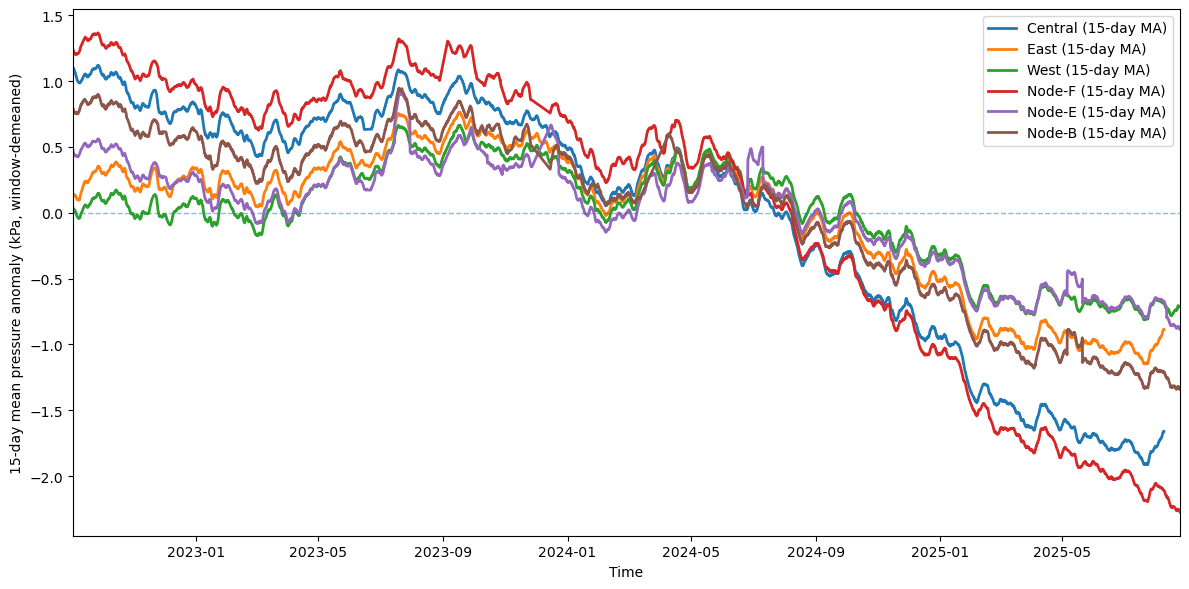

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

PSI_TO_KPA = 6.894757
COL_KPA = 'Corrected Pressure (kPa)'

start = pd.Timestamp('2022-09-02')
end   = pd.Timestamp('2025-08-25')

def to_ma15d(df, tcol, vcol, *, unit='kpa'):
    x = df[[tcol, vcol]].copy()
    x[tcol] = pd.to_datetime(x[tcol], errors='coerce')
    x = x.dropna(subset=[tcol]).sort_values(tcol)
    v = x[vcol].astype(float)
    if unit.lower() == 'psi':
        v = v * PSI_TO_KPA
    s = pd.Series(v.values, index=x[tcol])
    return s.rolling('15D', center=True, min_periods=1).mean()

def rebase_to_window(ma, start, end):
    w = ma.loc[start:end]
    return ma - w.mean()

# 15-day moving averages
ma_c  = to_ma15d(combined_df4, 'DateTime', COL_KPA, unit='kpa')
ma_e  = to_ma15d(combined_df2, 'DateTime', COL_KPA, unit='kpa')
ma_w  = to_ma15d(combined_df3, 'DateTime', COL_KPA, unit='kpa')
ma_cp = to_ma15d(cp,          'time',     'p',      unit='psi')  # cp.p is psi
ma_ep = to_ma15d(ep,          'time',     'p',      unit='psi')  # cp.p is psi
ma_wp = to_ma15d(wp,          'time',     'p',      unit='psi')  # cp.p is psi

# Re-baseline within the plotted window
ma_c  = rebase_to_window(ma_c,  start, end)
ma_e  = rebase_to_window(ma_e,  start, end)
ma_w  = rebase_to_window(ma_w,  start, end)
ma_cp = rebase_to_window(ma_cp, start, end)
ma_ep = rebase_to_window(ma_ep, start, end)
ma_wp = rebase_to_window(ma_wp, start, end)

# Plot only the window
plt.figure(figsize=(12, 6))
for s, name in [(ma_c, 'Central'), (ma_e, 'East'), (ma_w, 'West'), (ma_cp, 'Node-F'),(ma_ep, 'Node-E'),(ma_wp, 'Node-B')]:
    sw = s.loc[start:end]
    if not sw.empty:
        plt.plot(sw.index, sw.values, linewidth=2, label=f'{name} (15-day MA)')

plt.axhline(0, lw=1, ls='--', alpha=0.5)
plt.xlim(start, end)
plt.xlabel('Time')
plt.ylabel('15-day mean pressure anomaly (kPa, window-demeaned)')
plt.legend()
plt.tight_layout()
plt.show()


In [7]:

# -----------------------------
# Requested time windows
# -----------------------------
t0 = pd.Timestamp("2023-03-01")   # fit start
t1 = pd.Timestamp("2025-09-01")   # fit end (exclusive)

depth_start = pd.Timestamp("2022-09-02")
depth_end   = pd.Timestamp("2025-09-25")  # extended end

TOL = "2H"          # merge_asof tolerance (same as original)
USE_MA_FOR_FIT = True
MA_WIN = "15D"      # same as your workflow
CM_PER_KPA = 9.94   # your conversion

DO_EXTRAPOLATE = True
GRID_FREQ = "1D"

# If True, add a continuity offset to Pc-based extrapolation so the tail matches the last observed P_dc level.
USE_CONTINUITY_OFFSET = True


In [8]:

Pc = ma_cp.copy()

P_targets = {
    "Node-E": ma_ep.copy(),
    "Node-B": ma_wp.copy(),
    "Bench_Central": ma_c.copy(),
    "Bench_East": ma_e.copy(),
    "Bench_West": ma_w.copy(),
}

info = []
for k,s in {"Pc(Node-F)": Pc, **P_targets}.items():
    info.append([k, s.index.min(), s.index.max(), len(s)])
pd.DataFrame(info, columns=["series","tmin","tmax","n"]).set_index("series")


,tmin,tmax,n
series,,,
Pc(Node-F),2016-01-01 00:00:00,2025-09-15 00:28:00,19357227
Node-E,2014-09-04 00:00:00,2025-09-18 00:28:00,22445544
Node-B,2017-08-17 00:00:00,2025-09-19 00:28:00,15919019
Bench_Central,2022-09-02 11:45:00,2025-08-09 03:45:00,6372
Bench_East,2022-09-01 03:45:00,2025-08-09 07:45:00,6402
Bench_West,2022-09-01 11:45:00,2025-08-24 03:45:00,6516


In [9]:

import numpy as np
import pandas as pd

def _series_to_df(s, name):
    s = s.dropna()
    s.index = pd.to_datetime(s.index, errors="coerce")
    s = s[~s.index.isna()]
    df = s.rename(name).rename_axis("time").reset_index()

    # normalize timezone to naive
    for _ in range(2):
        try:
            df["time"] = df["time"].dt.tz_convert(None); break
        except Exception:
            try:
                df["time"] = df["time"].dt.tz_localize(None); break
            except Exception:
                pass

    df = df.sort_values("time")
    df = df[~df["time"].duplicated(keep="first")]
    return df

def align_P_and_Pc(P, Pc, tol="2H"):
    dfP = _series_to_df(P, "P")
    dfC = _series_to_df(Pc, "Pc")
    m = pd.merge_asof(dfP, dfC, on="time", direction="nearest", tolerance=pd.Timedelta(tol))
    m = m.dropna(subset=["P","Pc"]).sort_values("time").reset_index(drop=True)
    return m

def fit_P_a_bPc_c_tprime(m, t0, t1):
    mf = m[(m["time"] >= pd.Timestamp(t0)) & (m["time"] < pd.Timestamp(t1))].copy()
    if mf.empty:
        raise ValueError("No data in fit window after alignment.")

    t_mid = mf["time"].iloc[0] + (mf["time"].iloc[-1] - mf["time"].iloc[0]) / 2
    tprime = (mf["time"] - t_mid).dt.total_seconds().to_numpy(dtype=float) / (365.25*86400.0)

    X = np.column_stack([np.ones(len(mf)), mf["Pc"].to_numpy(float), tprime])
    y = mf["P"].to_numpy(float)
    a, b, c = np.linalg.lstsq(X, y, rcond=None)[0]

    yhat = X @ np.array([a,b,c])
    rmse = float(np.sqrt(np.mean((y - yhat)**2)))

    tprime_full = (m["time"] - t_mid).dt.total_seconds().to_numpy(dtype=float) / (365.25*86400.0)
    mout = m.copy()
    mout["tprime_years"] = tprime_full
    mout["drift_component"] = c * tprime_full
    mout["P_driftcorr"] = mout["P"] - mout["drift_component"]

    mout["Pc_only_pred_dc"] = a + b * mout["Pc"].to_numpy(float)
    mout["resid_dc"] = mout["P_driftcorr"] - mout["Pc_only_pred_dc"]

    fit = {
        "a": float(a), "b": float(b), "c_kPa_per_year": float(c),
        "rmse_kPa": rmse, "n_fit": int(len(mf)), "t_mid": t_mid
    }
    return fit, mout


In [10]:

fits = {}
aligned = {}

for name, P in P_targets.items():
    if USE_MA_FOR_FIT:
        P_use  = P.rolling(MA_WIN, center=True, min_periods=1).mean()
        Pc_use = Pc.rolling(MA_WIN, center=True, min_periods=1).mean()
    else:
        P_use, Pc_use = P, Pc

    m = align_P_and_Pc(P_use, Pc_use, tol=TOL)
    fit, mout = fit_P_a_bPc_c_tprime(m, t0=t0, t1=t1)
    fits[name] = fit
    aligned[name] = mout

pd.DataFrame(fits).T


,a,b,c_kPa_per_year,rmse_kPa,n_fit,t_mid
Node-E,0.038833,0.555288,0.329334,0.082178,4826108,2024-05-31 11:59:52.500
Node-B,0.022245,0.680224,0.140361,0.046438,4572681,2024-05-31 11:59:52.500
Bench_Central,-0.073221,0.835888,-0.015976,0.034073,4921,2024-05-20 03:45:00.000
Bench_East,0.022739,0.709711,0.323549,0.041333,4921,2024-05-20 05:45:00.000
Bench_West,0.08115,0.649048,0.458057,0.057252,5031,2024-05-27 15:45:00.000


In [11]:

# Coverage for each aligned target series (note: this does NOT truncate Pc itself)
cov = []
for name, mout in aligned.items():
    cov.append([name, pd.to_datetime(mout["time"]).min(), pd.to_datetime(mout["time"]).max(), len(mout)])
pd.DataFrame(cov, columns=["series","tmin_aligned","tmax_aligned","n"]).set_index("series")


,tmin_aligned,tmax_aligned,n
series,,,
Node-E,2015-12-31 22:00:00,2025-09-15 00:28:00,19315988
Node-B,2017-08-17 00:00:00,2025-09-15 02:28:00,15664251
Bench_Central,2022-09-02 11:45:00,2025-08-09 03:45:00,5947
Bench_East,2022-09-01 03:45:00,2025-08-09 07:45:00,5961
Bench_West,2022-09-01 11:45:00,2025-08-24 03:45:00,6075


In [14]:

grid = pd.date_range(depth_start, depth_end, freq=GRID_FREQ)

# ensure datetime index + sorted + unique
Pc = Pc.copy()
Pc.index = pd.to_datetime(Pc.index, errors="coerce")
Pc = Pc[~Pc.index.isna()]
Pc = Pc.sort_index()

# drop duplicate timestamps (keep first or last — pick one)
Pc = Pc[~Pc.index.duplicated(keep="last")]  # or keep="first"


# Pc on grid (interpolate in time)
Pc_grid = Pc.reindex(grid).interpolate("time")

dc_grid = {}
coverage = []

for name, mout in aligned.items():
    t = pd.to_datetime(mout["time"])
    s_dc = pd.Series(mout["P_driftcorr"].to_numpy(float), index=t).sort_index()

    first_obs = s_dc.index.min()
    last_obs  = s_dc.index.max()

    s_on = s_dc.reindex(grid).interpolate("time")

    needs_extrap = last_obs < pd.Timestamp(depth_end)
    if DO_EXTRAPOLATE and needs_extrap:
        tail = grid[grid > last_obs]
        a = fits[name]["a"]
        b = fits[name]["b"]
        pred = a + b * Pc_grid.loc[tail]

        if USE_CONTINUITY_OFFSET:
            # continuity offset from last observed day
            pc_last = float(Pc_grid.loc[last_obs]) if last_obs in Pc_grid.index else float(Pc_grid.reindex([last_obs]).interpolate("time").iloc[0])
            pred_last = a + b * pc_last
            resid_last = float(s_dc.loc[last_obs] - pred_last) if last_obs in s_dc.index else float(s_dc.iloc[-1] - pred_last)
            pred = pred + resid_last

        ok = np.isfinite(pred.to_numpy())
        s_on.loc[tail[ok]] = pred.to_numpy()[ok]

    dc_grid[name] = s_on.rename(f"{name}_driftcorr_kPa")

    coverage.append({
        "instrument": name,
        "first_obs": first_obs,
        "last_obs": last_obs,
        "needs_extrapolation": bool(needs_extrap),
        "has_value_at_depth_end": bool(np.isfinite(s_on.loc[pd.Timestamp(depth_end)])),
    })

pd.DataFrame(coverage).set_index("instrument")


,first_obs,last_obs,needs_extrapolation,has_value_at_depth_end
instrument,,,,
Node-E,2015-12-31 22:00:00,2025-09-15 00:28:00,True,True
Node-B,2017-08-17 00:00:00,2025-09-15 02:28:00,True,True
Bench_Central,2022-09-02 11:45:00,2025-08-09 03:45:00,True,False
Bench_East,2022-09-01 03:45:00,2025-08-09 07:45:00,True,False
Bench_West,2022-09-01 11:45:00,2025-08-24 03:45:00,True,False


In [21]:

def start_window_mean(s, start, days=7):
    start = pd.Timestamp(start)
    end = start + pd.Timedelta(days=days)
    w = s.loc[(s.index >= start) & (s.index < end)].dropna()
    return float(w.mean()) if len(w) else np.nan

def end_window_mean(s, end, days=7):
    end = pd.Timestamp(end)
    start = end - pd.Timedelta(days=days)
    w = s.loc[(s.index > start) & (s.index <= end)].dropna()
    return float(w.mean()) if len(w) else np.nan

rows = []
for name, s in dc_grid.items():
    p0 = start_window_mean(s, depth_start, days=7)
    p1 = end_window_mean(s, depth_end, days=7)
    dP = p1 - p0
    rows.append({
        "instrument": name,
        "P_start_mean_kPa": p0,
        "P_end_mean_kPa": p1,
        "deltaP_kPa": dP,
        "deltaDepth_cm": dP * CM_PER_KPA if np.isfinite(dP) else np.nan,
        "deltaDepth_m": (dP * CM_PER_KPA)/100.0 if np.isfinite(dP) else np.nan,
    })

depth_change = pd.DataFrame(rows).set_index("instrument")
depth_change


,P_start_mean_kPa,P_end_mean_kPa,deltaP_kPa,deltaDepth_cm,deltaDepth_m
instrument,,,,,
Node-E,1.028258,-1.367695,-2.395953,-23.815774,-0.238158
Node-B,1.030820,-1.663627,-2.694447,-26.782802,-0.267828
Bench_Central,NaN,NaN,NaN,NaN,NaN
Bench_East,NaN,NaN,NaN,NaN,NaN
Bench_West,NaN,NaN,NaN,NaN,NaN


/tmp/ipykernel_1927384/3914762982.py:19: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


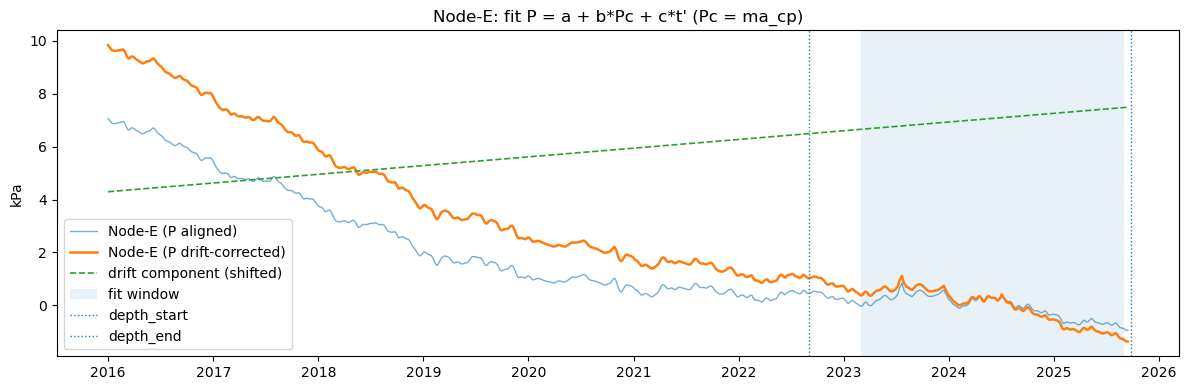

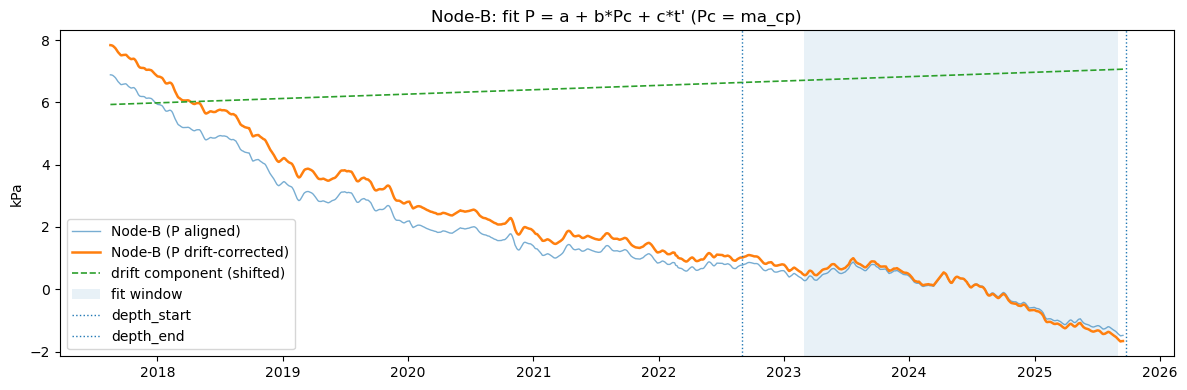

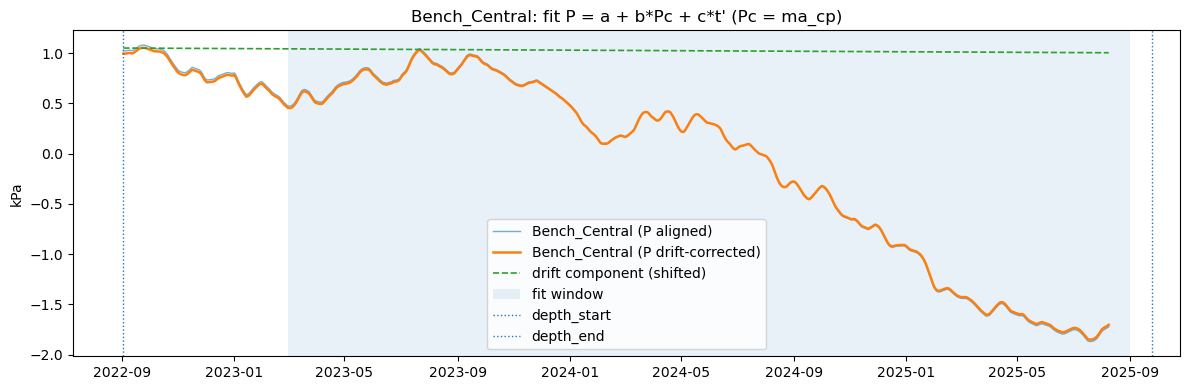

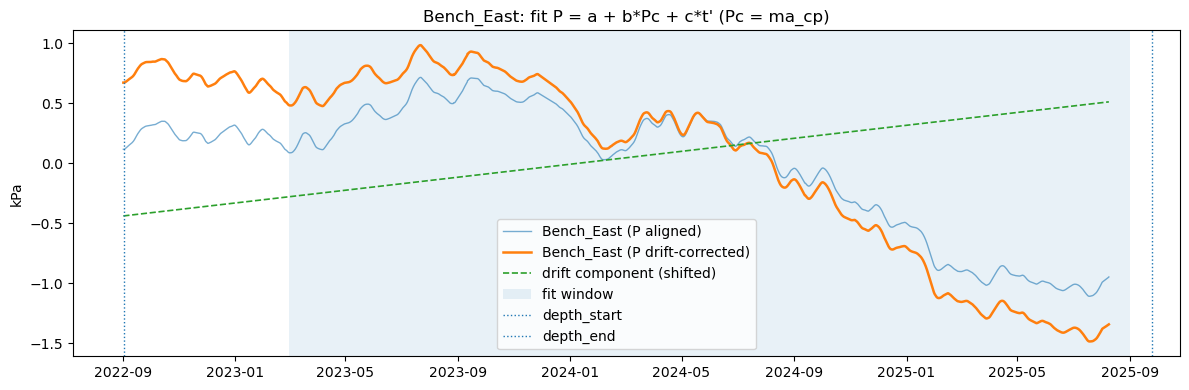

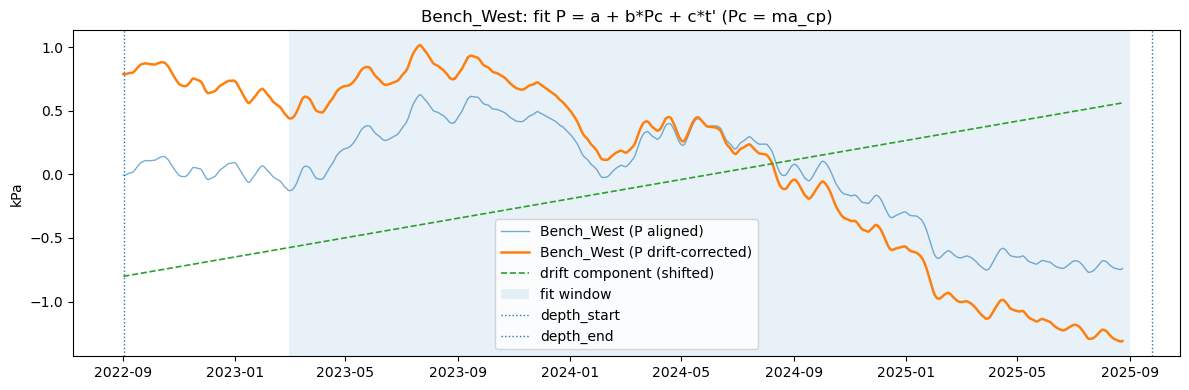

In [16]:

import matplotlib.pyplot as plt

for name, mout in aligned.items():
    t = pd.to_datetime(mout["time"])
    P = mout["P"].to_numpy(float)
    drift = mout["drift_component"].to_numpy(float)
    Pdc = mout["P_driftcorr"].to_numpy(float)

    plt.figure(figsize=(12,4))
    plt.plot(t, P, lw=1, alpha=0.6, label=f"{name} (P aligned)")
    plt.plot(t, Pdc, lw=1.8, label=f"{name} (P drift-corrected)")
    plt.plot(t, drift + P[0], lw=1.2, ls="--", label="drift component (shifted)")
    plt.axvspan(pd.Timestamp(t0), pd.Timestamp(t1), alpha=0.1, label="fit window")
    plt.axvline(pd.Timestamp(depth_start), lw=1, ls=":", label="depth_start")
    plt.axvline(pd.Timestamp(depth_end), lw=1, ls=":", label="depth_end")
    plt.ylabel("kPa")
    plt.title(f"{name}: fit P = a + b*Pc + c*t' (Pc = ma_cp)")
    plt.legend()
    plt.tight_layout()
    plt.show()


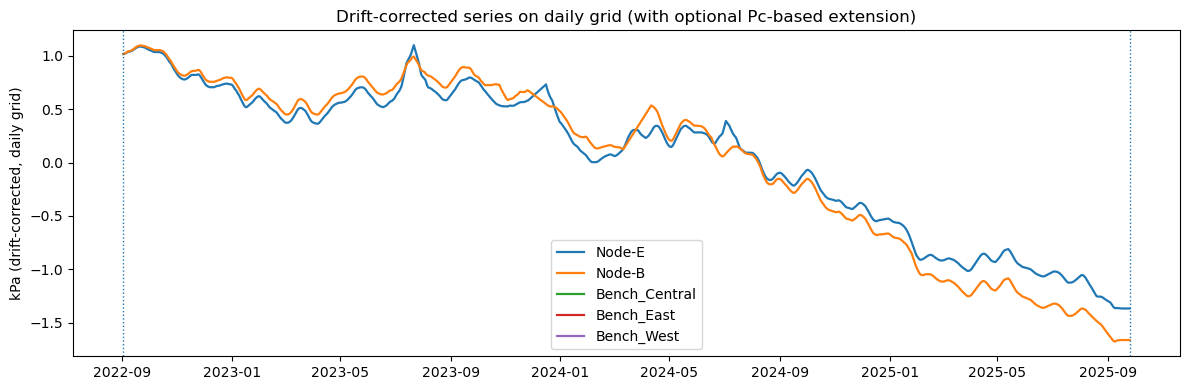

In [17]:

# Daily-grid view (shows extrapolated tail if used)
plt.figure(figsize=(12,4))
for name, s in dc_grid.items():
    plt.plot(s.index, s.values, lw=1.6, label=name)
plt.axvline(pd.Timestamp(depth_start), lw=1, ls=":")
plt.axvline(pd.Timestamp(depth_end), lw=1, ls=":")
plt.ylabel("kPa (drift-corrected, daily grid)")
plt.title("Drift-corrected series on daily grid (with optional Pc-based extension)")
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
dc_grid

{'Node-F': 2022-09-02    1.238421
 2022-09-03    1.217812
 2022-09-04    1.206779
 2022-09-05    1.205851
 2022-09-06    1.207248
                 ...   
 2025-09-21   -2.558978
 2025-09-22   -2.558978
 2025-09-23   -2.558978
 2025-09-24   -2.558978
 2025-09-25   -2.558978
 Freq: D, Name: Node-F_driftcorr_kPa, Length: 1120, dtype: float64,
 'Node-E': 2022-09-02    1.017980
 2022-09-03    1.020184
 2022-09-04    1.022999
 2022-09-05    1.026825
 2022-09-06    1.032240
                 ...   
 2025-09-21   -1.367727
 2025-09-22   -1.367727
 2025-09-23   -1.367727
 2025-09-24   -1.367727
 2025-09-25   -1.367727
 Freq: D, Name: Node-E_driftcorr_kPa, Length: 1120, dtype: float64,
 'Node-B': 2022-09-02    1.018232
 2022-09-03    1.021467
 2022-09-04    1.025212
 2022-09-05    1.029811
 2022-09-06    1.035704
                 ...   
 2025-09-21   -1.663669
 2025-09-22   -1.663669
 2025-09-23   -1.663669
 2025-09-24   -1.663669
 2025-09-25   -1.663669
 Freq: D, Name: Node-B_driftcorr_kPa, Leng

In [18]:

from pathlib import Path

out_dir = Path("drift_corrected_outputs_extended")
out_dir.mkdir(exist_ok=True)

for name, s in dc_grid.items():
    out = pd.DataFrame({"time": s.index, "pressure_drift_corrected_kPa": s.values})
    out_file = out_dir / f"{name}_driftcorr_daily_{depth_start.date()}_{depth_end.date()}.csv"
    out.to_csv(out_file, index=False)

print(f"Wrote {len(dc_grid)} files to: {out_dir.resolve()}")


Wrote 5 files to: /home/seismic/AxialFetch/drift_corrected_outputs_extended


In [26]:
import numpy as np
import pandas as pd

# =======================
# INPUTS (from your notebook)
# =======================
Pc = ma_cp.copy()  # Node-F (reference)

P_targets = {
    "Node-E": ma_ep.copy(),
    "Node-B": ma_wp.copy(),
    "Bench_Central": ma_c.copy(),
    "Bench_East": ma_e.copy(),
    "Bench_West": ma_w.copy(),
}

# =======================
# SETTINGS
# =======================
t0 = pd.Timestamp("2023-03-01")    # fit start
t1 = pd.Timestamp("2025-09-01")    # fit end (exclusive)

depth_start = pd.Timestamp("2022-09-02")
depth_end   = pd.Timestamp("2025-09-25")   # you want to go to this date

TOL = "2H"                 # asof tolerance
USE_MA_FOR_FIT = True
MA_WIN = "15D"              # like your workflow
DO_EXTRAPOLATE = True
USE_CONTINUITY_OFFSET = True

CM_PER_KPA = 9.94           # cm per kPa
SAMPLE_FREQ = "1H"          # sampling for window means (robust to timestamp offsets)

# =======================
# HELPERS
# =======================
def clean_series(s, keep="last"):
    s = s.copy()
    s.index = pd.to_datetime(s.index, errors="coerce")
    s = s[~s.index.isna()].sort_index()
    s = s[~s.index.duplicated(keep=keep)]
    # force tz-naive
    try:
        s.index = s.index.tz_convert(None)
    except Exception:
        try:
            s.index = s.index.tz_localize(None)
        except Exception:
            pass
    return s

def asof_align(P, Pc, tol="2H"):
    dfP = P.dropna().rename("P").rename_axis("time").reset_index()
    dfC = Pc.dropna().rename("Pc").rename_axis("time").reset_index()
    dfP["time"] = pd.to_datetime(dfP["time"], errors="coerce")
    dfC["time"] = pd.to_datetime(dfC["time"], errors="coerce")
    dfP = dfP.dropna(subset=["time"]).sort_values("time")
    dfC = dfC.dropna(subset=["time"]).sort_values("time")
    # tz-naive
    for df in (dfP, dfC):
        for _ in range(2):
            try:
                df["time"] = df["time"].dt.tz_convert(None); break
            except Exception:
                try:
                    df["time"] = df["time"].dt.tz_localize(None); break
                except Exception:
                    pass
    m = pd.merge_asof(dfP, dfC, on="time", direction="nearest", tolerance=pd.Timedelta(tol))
    m = m.dropna(subset=["P","Pc"]).sort_values("time").reset_index(drop=True)
    return m

def fit_P_a_bPc_c_tprime(m, t0, t1):
    mf = m[(m["time"] >= t0) & (m["time"] < t1)].copy()
    if mf.empty:
        raise ValueError("No aligned samples in fit window. Check Pc coverage / TOL / timestamps.")

    t_mid = mf["time"].iloc[0] + (mf["time"].iloc[-1] - mf["time"].iloc[0]) / 2
    tprime = (mf["time"] - t_mid).dt.total_seconds().to_numpy(float) / (365.25*86400.0)

    X = np.column_stack([np.ones(len(mf)), mf["Pc"].to_numpy(float), tprime])
    y = mf["P"].to_numpy(float)
    a, b, c = np.linalg.lstsq(X, y, rcond=None)[0]

    # build drift-corrected series on ALL aligned timestamps
    tprime_full = (m["time"] - t_mid).dt.total_seconds().to_numpy(float) / (365.25*86400.0)
    P_dc = m["P"].to_numpy(float) - c * tprime_full

    fit = {"a": float(a), "b": float(b), "c_kPa_per_year": float(c), "t_mid": t_mid}
    s_dc = pd.Series(P_dc, index=pd.to_datetime(m["time"]).to_numpy()).sort_index()
    s_dc = clean_series(s_dc)
    return fit, s_dc

def interp_series_at_times(s, t_index):
    # time interpolation on arbitrary timestamps
    s2 = s.reindex(s.index.union(t_index)).sort_index().interpolate("time")
    return s2.reindex(t_index)

def window_mean_from_function(eval_func, t_start, t_end, freq="1H"):
    # sample densely inside the window and average (robust to irregular sampling)
    ts = pd.date_range(t_start, t_end, freq=freq, inclusive="left")
    vals = eval_func(ts)
    vals = pd.Series(vals, index=ts).dropna()
    return float(vals.mean()) if len(vals) else np.nan

# =======================
# CLEAN INPUTS
# =======================
Pc = clean_series(Pc)
P_targets = {k: clean_series(v) for k,v in P_targets.items()}

# Pc interpolator (for extrapolation)
def Pc_at(times):
    times = pd.DatetimeIndex(pd.to_datetime(times))
    return interp_series_at_times(Pc, times).to_numpy(float)

# =======================
# FIT + BUILD EVALUATORS
# =======================
evaluators = {}   # name -> function(times)->values
meta = {}

# Node-F (Pc) evaluator (no drift removal applied here; it's the reference)
evaluators["Node-F"] = lambda times: Pc_at(times)
meta["Node-F"] = {"first_obs": Pc.index.min(), "last_obs": Pc.index.max(),
                  "needs_extrapolation": bool(Pc.index.max() < depth_end),
                  "used_extrapolation": False, "c_kPa_per_year": np.nan}

fits = {}

for name, P in P_targets.items():
    # optional MA for fit stability
    if USE_MA_FOR_FIT:
        P_use  = P.rolling(MA_WIN, center=True, min_periods=1).mean()
        Pc_use = Pc.rolling(MA_WIN, center=True, min_periods=1).mean()
    else:
        P_use, Pc_use = P, Pc

    m = asof_align(P_use, Pc_use, tol=TOL)
    fit, s_dc = fit_P_a_bPc_c_tprime(m, t0, t1)
    fits[name] = fit

    first_obs = s_dc.index.min()
    last_obs  = s_dc.index.max()
    needs_ex = bool(last_obs < depth_end)

    # continuity residual at last_obs (relative to a + b*Pc)
    a, b = fit["a"], fit["b"]
    pc_last = float(Pc_at([last_obs])[0])
    resid_last = float(s_dc.loc[last_obs] - (a + b*pc_last))

    def make_eval(s_dc_local, a, b, last_obs, resid_last, do_extrap, use_offset):
        def _eval(times):
            times = pd.DatetimeIndex(pd.to_datetime(times))
            out = np.full(len(times), np.nan, dtype=float)

            # part 1: within observed range -> interpolate s_dc
            in_obs = times <= last_obs
            if np.any(in_obs):
                out[in_obs] = interp_series_at_times(s_dc_local, times[in_obs]).to_numpy(float)

            # part 2: after last_obs -> extrapolate using a + b*Pc (+ continuity offset)
            if do_extrap:
                after = times > last_obs
                if np.any(after):
                    pc_vals = Pc_at(times[after])
                    pred = a + b*pc_vals
                    if use_offset:
                        pred = pred + resid_last
                    out[after] = pred

            return out
        return _eval

    evaluators[name] = make_eval(
        s_dc_local=s_dc, a=a, b=b, last_obs=last_obs,
        resid_last=resid_last,
        do_extrap=(DO_EXTRAPOLATE and needs_ex),
        use_offset=USE_CONTINUITY_OFFSET
    )

    meta[name] = {
        "first_obs": first_obs,
        "last_obs": last_obs,
        "needs_extrapolation": needs_ex,
        "used_extrapolation": bool(DO_EXTRAPOLATE and needs_ex),
        "c_kPa_per_year": fit["c_kPa_per_year"],
    }

# =======================
# DEPTH CHANGE TABLE (ALL SERIES)
# =======================
rows = []
for name, eval_func in evaluators.items():
    p0 = window_mean_from_function(eval_func, depth_start, depth_start + pd.Timedelta(days=7), freq=SAMPLE_FREQ)
    p1 = window_mean_from_function(eval_func, depth_end - pd.Timedelta(days=7), depth_end, freq=SAMPLE_FREQ)
    dP = p1 - p0
    rows.append({
        "instrument": name,
        "P_start_mean_kPa": p0,
        "P_end_mean_kPa": p1,
        "deltaP_kPa": dP,
        "deltaDepth_cm": dP * CM_PER_KPA if np.isfinite(dP) else np.nan,
        "deltaDepth_m": (dP * CM_PER_KPA)/100.0 if np.isfinite(dP) else np.nan,
        **meta.get(name, {})
    })

depth_change_all = pd.DataFrame(rows).set_index("instrument").sort_index()
depth_change_all


,P_start_mean_kPa,P_end_mean_kPa,deltaP_kPa,deltaDepth_cm,deltaDepth_m,first_obs,last_obs,needs_extrapolation,used_extrapolation,c_kPa_per_year
instrument,,,,,,,,,,
Bench_Central,0.997787,-2.078277,-3.076064,-30.576072,-0.305761,2022-09-02 11:45:00,2025-08-09 03:45:00,True,True,-0.015894
Bench_East,0.691132,-1.660210,-2.351342,-23.372337,-0.233723,2022-09-01 03:45:00,2025-08-09 07:45:00,True,True,0.323642
Bench_West,0.791502,-1.502906,-2.294408,-22.806416,-0.228064,2022-09-01 11:45:00,2025-08-24 03:45:00,True,True,0.458154
Node-B,1.032855,-1.663582,-2.696438,-26.802589,-0.268026,2017-08-17 00:00:00,2025-09-15 02:28:00,True,True,0.140393
Node-E,1.029932,-1.367747,-2.397678,-23.832923,-0.238329,2015-12-31 22:00:00,2025-09-15 00:28:00,True,True,0.329358
Node-F,1.214265,-2.558670,-3.772935,-37.502977,-0.375030,2016-01-01 00:00:00,2025-09-15 00:28:00,True,False,NaN


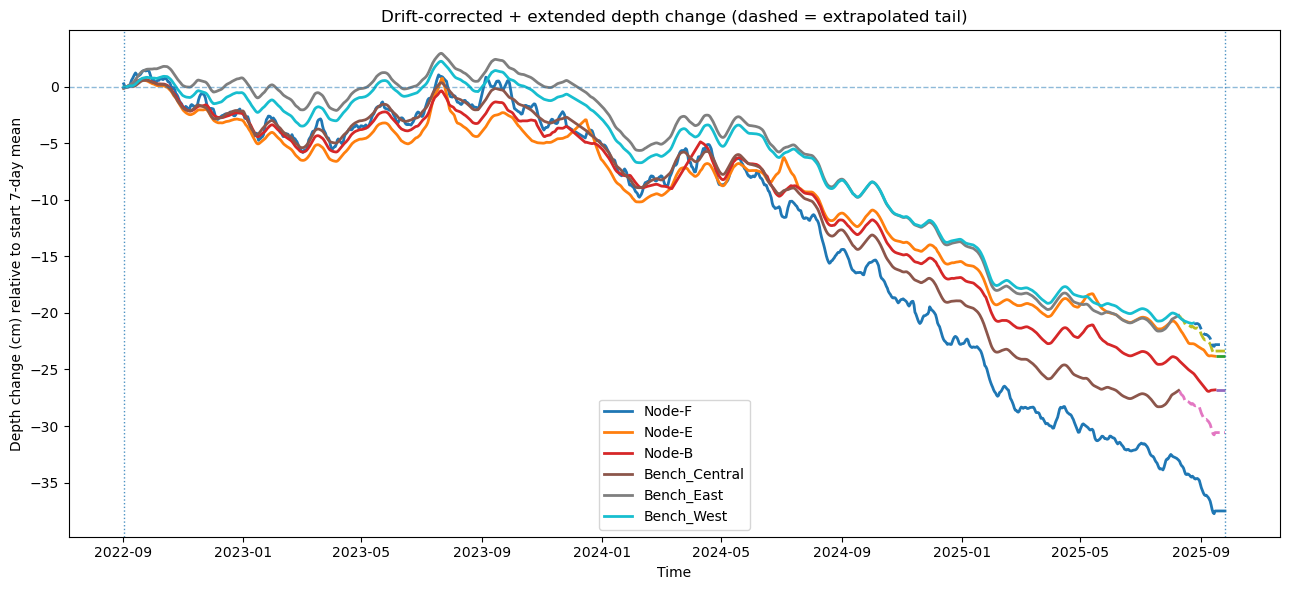

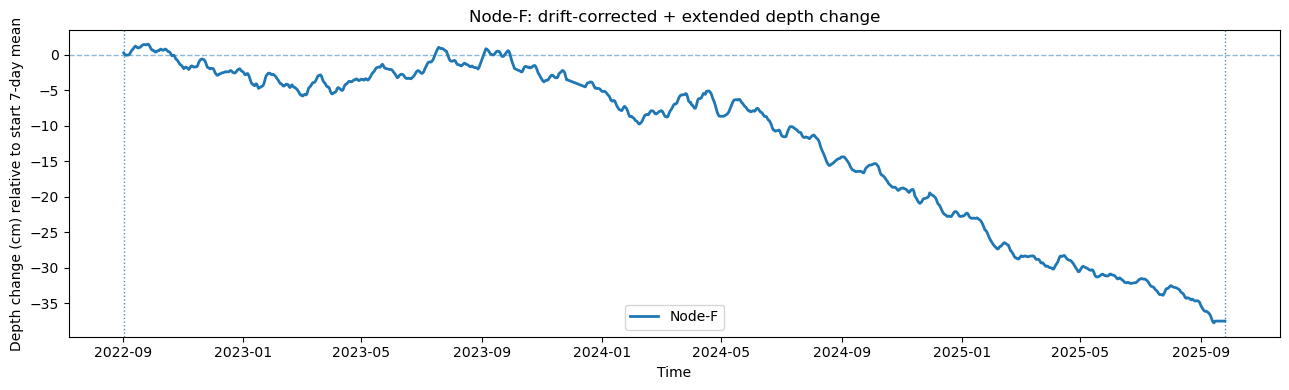

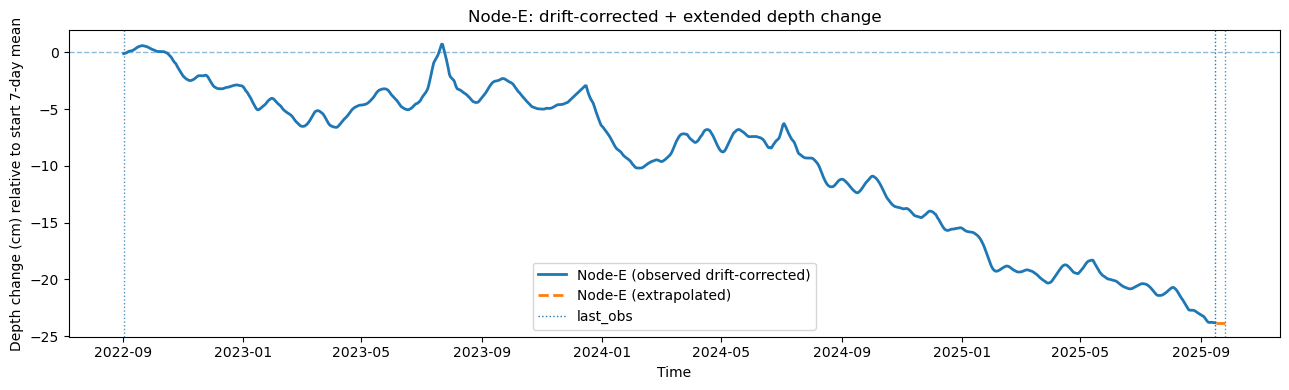

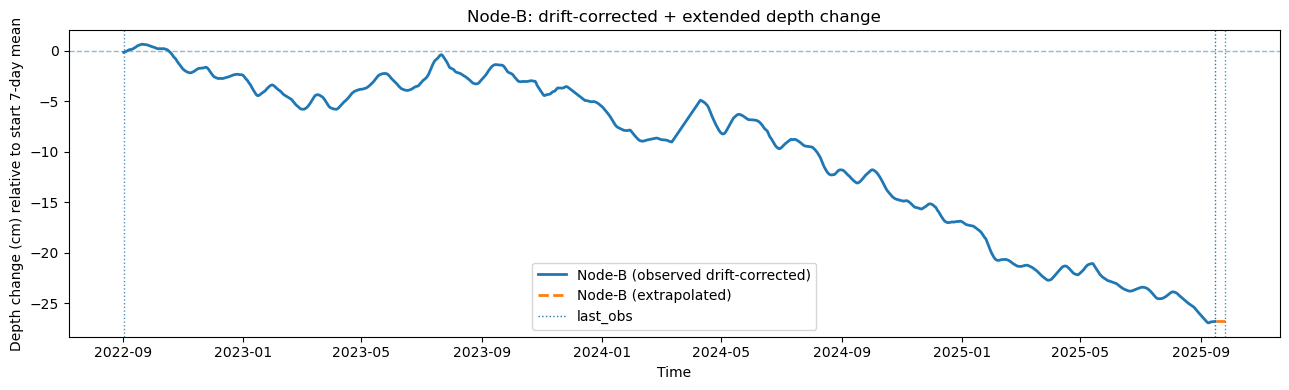

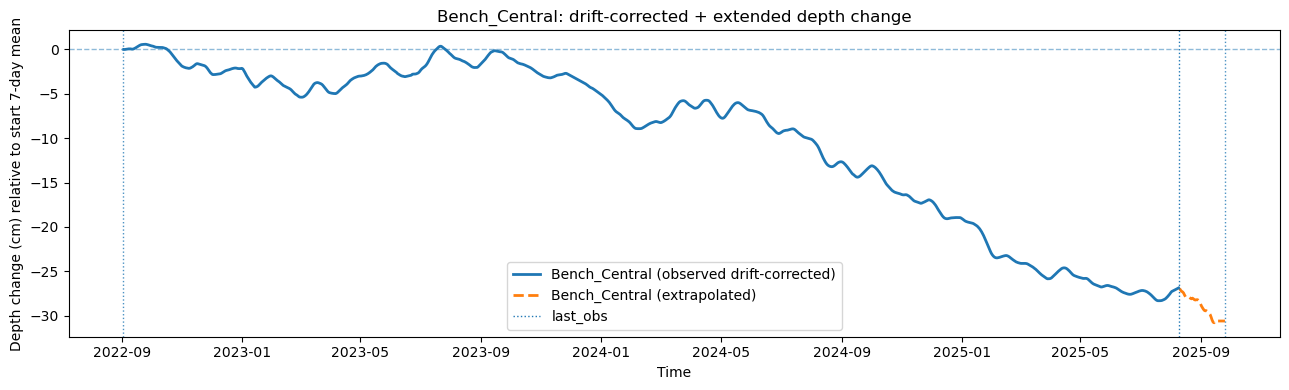

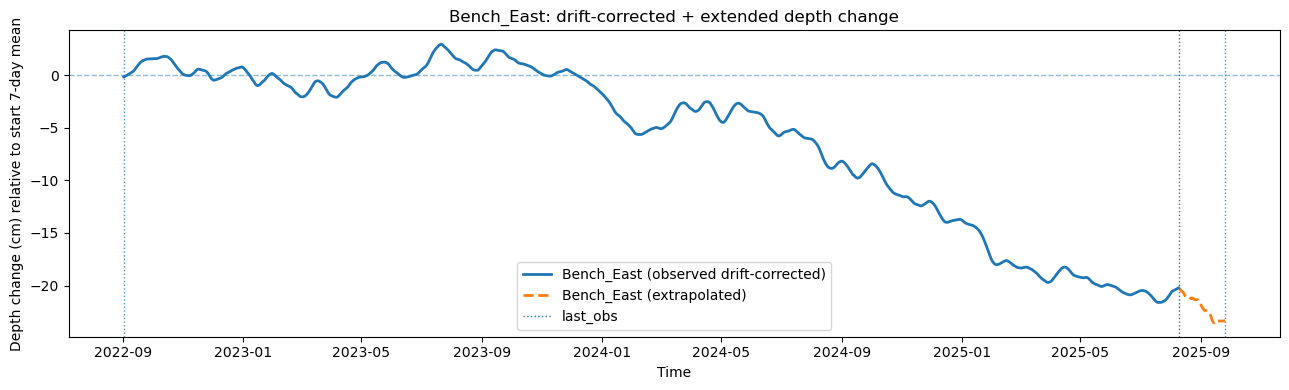

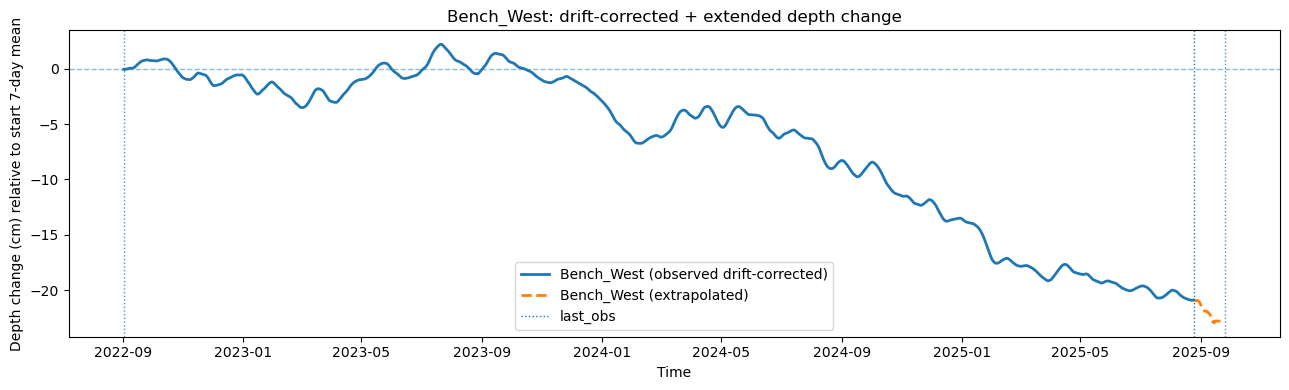

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------- settings for plotting --------
PLOT_FREQ = "1D"          # sampling for plotted curve (change to "6H" if you want smoother)
BASELINE_DAYS = 7         # baseline mean at start
YLABEL = "Depth change (cm) relative to start 7-day mean"

def eval_series_on_grid(name, eval_func, grid):
    y = eval_func(grid)
    y = pd.Series(y, index=grid).astype(float)
    return y

def baseline_mean(eval_func, start, days=7, freq="1H"):
    t0 = pd.Timestamp(start)
    t1 = t0 + pd.Timedelta(days=days)
    tt = pd.date_range(t0, t1, freq=freq, inclusive="left")
    yy = pd.Series(eval_func(tt), index=tt).astype(float).dropna()
    return float(yy.mean()) if len(yy) else np.nan

# time grid for the plotted curves
grid = pd.date_range(depth_start, depth_end, freq=PLOT_FREQ)

# ---------- PLOT 1: all instruments depth change (cm), dashed where extrapolated ----------
plt.figure(figsize=(13,6))

for name, eval_func in evaluators.items():
    p0 = baseline_mean(eval_func, depth_start, days=BASELINE_DAYS, freq="1H")
    sP = eval_series_on_grid(name, eval_func, grid)

    # convert to depth change (cm) relative to start-window mean
    sDepth_cm = (sP - p0) * CM_PER_KPA

    # plot observed part (up to last_obs if known)
    last_obs = meta.get(name, {}).get("last_obs", None)
    used_ex = bool(meta.get(name, {}).get("used_extrapolation", False))

    if (last_obs is not None) and used_ex:
        last_obs = pd.Timestamp(last_obs)
        obs = sDepth_cm.loc[sDepth_cm.index <= last_obs]
        ext = sDepth_cm.loc[sDepth_cm.index >  last_obs]

        plt.plot(obs.index, obs.values, lw=2, label=name)
        if len(ext):
            plt.plot(ext.index, ext.values, lw=2, ls="--")  # extrapolated tail
    else:
        plt.plot(sDepth_cm.index, sDepth_cm.values, lw=2, label=name)

plt.axhline(0, lw=1, ls="--", alpha=0.5)
plt.axvline(pd.Timestamp(depth_start), lw=1, ls=":", alpha=0.8)
plt.axvline(pd.Timestamp(depth_end),   lw=1, ls=":", alpha=0.8)
plt.xlabel("Time")
plt.ylabel(YLABEL)
plt.title("Drift-corrected + extended depth change (dashed = extrapolated tail)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- PLOT 2: one instrument per figure (cleaner if many overlap) ----------
for name, eval_func in evaluators.items():
    p0 = baseline_mean(eval_func, depth_start, days=BASELINE_DAYS, freq="1H")
    sP = eval_series_on_grid(name, eval_func, grid)
    sDepth_cm = (sP - p0) * CM_PER_KPA

    last_obs = meta.get(name, {}).get("last_obs", None)
    used_ex = bool(meta.get(name, {}).get("used_extrapolation", False))

    plt.figure(figsize=(13,4))
    if (last_obs is not None) and used_ex:
        last_obs = pd.Timestamp(last_obs)
        obs = sDepth_cm.loc[sDepth_cm.index <= last_obs]
        ext = sDepth_cm.loc[sDepth_cm.index >  last_obs]
        plt.plot(obs.index, obs.values, lw=2, label=f"{name} (observed drift-corrected)")
        if len(ext):
            plt.plot(ext.index, ext.values, lw=2, ls="--", label=f"{name} (extrapolated)")
        plt.axvline(last_obs, lw=1, ls=":", label="last_obs")
    else:
        plt.plot(sDepth_cm.index, sDepth_cm.values, lw=2, label=name)

    plt.axhline(0, lw=1, ls="--", alpha=0.5)
    plt.axvline(pd.Timestamp(depth_start), lw=1, ls=":", alpha=0.8)
    plt.axvline(pd.Timestamp(depth_end),   lw=1, ls=":", alpha=0.8)
    plt.xlabel("Time")
    plt.ylabel(YLABEL)
    plt.title(f"{name}: drift-corrected + extended depth change")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [33]:
import numpy as np
import pandas as pd

# =======================
# INPUTS (from your notebook)
# =======================
series_raw = {
    "Node-F":        ma_cp.copy(),  # Pc
    "Node-E":        ma_ep.copy(),  # ep
    "Node-B":        ma_wp.copy(),  # wp
    "Bench_Central": ma_c.copy(),   # Pn
    "Bench_East":    ma_e.copy(),   # Pe
    "Bench_West":    ma_w.copy(),   # Pw
}

Pc_name = "Node-F"

# =======================
# YOUR SPECIFIED MODELS (RAW Pc coupling) + YOUR SPECIFIED DRIFTS
#   P_raw ~ a + b*Pc_raw + c*t'    (t' in years, centered at t_mid you specify)
# Drift-corrected: P_dc(t) = P_raw(t) - c*t'
# Extrapolated tail (after last_obs): P_dc_pred(t) = a + b*Pc_raw(t) + resid_last
# =======================
models = {
    "Node-F":        {"a": 0.0,   "b": 1.0,   "c": 0.0,     "fit_start": "2023-03-01", "fit_end": "2025-09-01"},  # drift=0
    "Node-B":        {"a": 0.0032,   "b": 0.6437,   "c": 0.0662,  "fit_start": "2022-09-01", "fit_end": "2025-09-01"},
    "Node-E":        {"a": -0.0166,  "b": 0.5011,   "c": 0.2125,  "fit_start": "2022-09-01", "fit_end": "2025-09-01"},
    "Bench_Central": {"a": -0.0839,  "b": 0.8443,   "c": -0.0043, "fit_start": "2023-03-01", "fit_end": "2025-09-01"},
    "Bench_East":    {"a": 0.0081,   "b": 0.7182,   "c": 0.3335,  "fit_start": "2023-03-01", "fit_end": "2025-09-01"},
    "Bench_West":    {"a": 0.0570,   "b": 0.6671,   "c": 0.4818,  "fit_start": "2023-03-01", "fit_end": "2025-09-01"},
}

# =======================
# SETTINGS
# =======================
depth_start = pd.Timestamp("2022-09-02")
depth_end   = pd.Timestamp("2025-08-25")

DO_EXTRAPOLATE = True
USE_CONTINUITY_OFFSET = True

CM_PER_KPA = 9.94
SAMPLE_FREQ = "1H"  # for robust 7-day mean sampling

# =======================
# HELPERS
# =======================
def clean_series(s, keep="last"):
    s = s.copy()
    s.index = pd.to_datetime(s.index, errors="coerce")
    s = s[~s.index.isna()].sort_index()
    s = s[~s.index.duplicated(keep=keep)]
    # force tz-naive
    try:
        s.index = s.index.tz_convert(None)
    except Exception:
        try:
            s.index = s.index.tz_localize(None)
        except Exception:
            pass
    return s

def interp_series_at_times(s, t_index):
    t_index = pd.DatetimeIndex(pd.to_datetime(t_index))
    s2 = s.reindex(s.index.union(t_index)).sort_index().interpolate("time")
    return s2.reindex(t_index)

def years_since(t, t_mid):
    return (pd.DatetimeIndex(t) - pd.Timestamp(t_mid)).total_seconds().to_numpy(float) / (365.25 * 86400.0)

def window_mean_from_function(eval_func, t_start, t_end, freq="1H"):
    ts = pd.date_range(pd.Timestamp(t_start), pd.Timestamp(t_end), freq=freq, inclusive="left")
    vals = pd.Series(eval_func(ts), index=ts).dropna()
    return float(vals.mean()) if len(vals) else np.nan

# =======================
# CLEAN INPUT SERIES
# =======================
series_raw = {k: clean_series(v) for k,v in series_raw.items()}
Pc = series_raw[Pc_name]

def Pc_at(times):
    return interp_series_at_times(Pc, times).to_numpy(float)

# =======================
# BUILD DRIFT-CORRECTED SERIES + EVALUATORS (with extension)
# =======================
evaluators = {}
meta = {}

for name, Praw in series_raw.items():
    m = models[name]
    c = float(m["c"])

    # define t_mid from YOUR stated fit window center
    fit_start = pd.Timestamp(m["fit_start"])
    fit_end   = pd.Timestamp(m["fit_end"])
    t_mid = fit_start + (fit_end - fit_start)/2

    # drift-correct raw on its own timestamps
    t_obs = Praw.index
    tprime = years_since(t_obs, t_mid)
    Pdc = Praw.to_numpy(float) - c * tprime
    s_dc = clean_series(pd.Series(Pdc, index=t_obs))

    first_obs = s_dc.index.min()
    last_obs  = s_dc.index.max()
    needs_ex = bool(last_obs < depth_end)

    # if we have a,b, compute continuity residual at last_obs
    a = m["a"]; b = m["b"]
    resid_last = np.nan
    if np.isfinite(a) and np.isfinite(b):
        pc_last = float(Pc_at([last_obs])[0])
        resid_last = float(s_dc.loc[last_obs] - (a + b*pc_last))

    def make_eval(s_dc_local, last_obs_local, a, b, resid_last, do_extrap, use_offset):
        def _eval(times):
            times = pd.DatetimeIndex(pd.to_datetime(times))
            out = np.full(len(times), np.nan, dtype=float)

            # observed portion: interpolate drift-corrected series
            in_obs = times <= last_obs_local
            if np.any(in_obs):
                out[in_obs] = interp_series_at_times(s_dc_local, times[in_obs]).to_numpy(float)

            # extended tail: a + b*Pc (+ continuity residual)
            if do_extrap and np.isfinite(a) and np.isfinite(b):
                after = times > last_obs_local
                if np.any(after):
                    pc_vals = Pc_at(times[after])
                    pred = a + b * pc_vals
                    if use_offset and np.isfinite(resid_last):
                        pred = pred + resid_last
                    out[after] = pred

            return out
        return _eval

    used_ex = bool(DO_EXTRAPOLATE and needs_ex and np.isfinite(a) and np.isfinite(b))
    evaluators[name] = make_eval(
        s_dc_local=s_dc,
        last_obs_local=last_obs,
        a=a, b=b, resid_last=resid_last,
        do_extrap=used_ex,
        use_offset=USE_CONTINUITY_OFFSET
    )

    meta[name] = {
        "a": a, "b": b, "c_kPa_per_year": c,
        "t_mid": t_mid,
        "first_obs": first_obs,
        "last_obs": last_obs,
        "needs_extrapolation": needs_ex,
        "used_extrapolation": used_ex
    }

# =======================
# DEPTH CHANGE TABLE (ALL SERIES) — 7-day start mean vs 7-day end mean
# =======================
rows = []
for name, eval_func in evaluators.items():
    p0 = window_mean_from_function(eval_func, depth_start, depth_start + pd.Timedelta(days=7), freq=SAMPLE_FREQ)
    p1 = window_mean_from_function(eval_func, depth_end - pd.Timedelta(days=7), depth_end, freq=SAMPLE_FREQ)
    dP = p1 - p0
    rows.append({
        "instrument": name,
        "P_start_mean_kPa": p0,
        "P_end_mean_kPa": p1,
        "deltaP_kPa": dP,
        "deltaDepth_cm": dP * CM_PER_KPA if np.isfinite(dP) else np.nan,
        "deltaDepth_m": (dP * CM_PER_KPA)/100.0 if np.isfinite(dP) else np.nan,
        **meta[name]
    })

depth_change_all = pd.DataFrame(rows).set_index("instrument").sort_index()
depth_change_all


,P_start_mean_kPa,P_end_mean_kPa,deltaP_kPa,deltaDepth_cm,deltaDepth_m,a,b,c_kPa_per_year,t_mid,first_obs,last_obs,needs_extrapolation,used_extrapolation
instrument,,,,,,,,,,,,,
Bench_Central,1.020445,-1.773494,-2.793939,-27.771750,-0.277717,-0.0839,0.8443,-0.0043,2024-05-31 12:00:00,2022-09-02 11:45:00,2025-08-09 03:45:00,True,True
Bench_East,0.694760,-1.385925,-2.080685,-20.682005,-0.206820,0.0081,0.7182,0.3335,2024-05-31 12:00:00,2022-09-01 03:45:00,2025-08-09 07:45:00,True,True
Bench_West,0.826328,-1.322440,-2.148767,-21.358748,-0.213587,0.0570,0.6671,0.4818,2024-05-31 12:00:00,2022-09-01 11:45:00,2025-08-24 03:45:00,True,True
Node-B,0.865462,-1.424226,-2.289688,-22.759497,-0.227595,0.0032,0.6437,0.0662,2024-03-02 00:00:00,2017-08-17 00:00:00,2025-09-19 00:28:00,False,False
Node-E,0.754490,-1.177127,-1.931617,-19.200272,-0.192003,-0.0166,0.5011,0.2125,2024-03-02 00:00:00,2014-09-04 00:00:00,2025-09-18 00:28:00,False,False
Node-F,1.214265,-2.249367,-3.463632,-34.428504,-0.344285,0.0000,1.0000,0.0000,2024-05-31 12:00:00,2016-01-01 00:00:00,2025-09-15 00:28:00,False,False


In [37]:
import numpy as np
import pandas as pd

# =======================
# INPUTS (from your notebook)
# =======================
series_raw = {
    "Node-F":        ma_cp.copy(),  # Pc
    "Node-E":        ma_ep.copy(),  # ep
    "Node-B":        ma_wp.copy(),  # wp
    "Bench_Central": ma_c.copy(),   # Pn
    "Bench_East":    ma_e.copy(),   # Pe
    "Bench_West":    ma_w.copy(),   # Pw
}

Pc_name = "Node-F"

# =======================
# YOUR SPECIFIED MODELS (RAW Pc coupling) + YOUR SPECIFIED DRIFTS
#   P_raw ~ a + b*Pc_raw + c*t'    (t' in years, centered at t_mid you specify)
# Drift-corrected: P_dc(t) = P_raw(t) - c*t'
# Extrapolated tail (after last_obs): P_dc_pred(t) = a + b*Pc_raw(t) + resid_last
# =======================
models = {
    "Node-F":        {"a": 0.0,   "b": 1.0,   "c": 0.0,     "fit_start": "2023-03-01", "fit_end": "2025-09-01"},  # drift=0
    "Node-B":        {"a": 0.0032,   "b": 0.6437,   "c": 0.0662,  "fit_start": "2022-09-01", "fit_end": "2025-09-01"},
    "Node-E":        {"a": -0.0166,  "b": 0.5011,   "c": 0.2125,  "fit_start": "2022-09-01", "fit_end": "2025-09-01"},
    "Bench_Central": {"a": -0.0839,  "b": 0.8443,   "c": -0.0043, "fit_start": "2023-03-01", "fit_end": "2025-09-01"},
    "Bench_East":    {"a": 0.0081,   "b": 0.7182,   "c": 0.3335,  "fit_start": "2023-03-01", "fit_end": "2025-09-01"},
    "Bench_West":    {"a": 0.0570,   "b": 0.6671,   "c": 0.4818,  "fit_start": "2023-03-01", "fit_end": "2025-09-01"},
}

# =======================
# SETTINGS
# =======================
depth_start = pd.Timestamp("2022-09-02")
depth_end   = pd.Timestamp("2025-08-09")

DO_EXTRAPOLATE = True
USE_CONTINUITY_OFFSET = True

CM_PER_KPA = 9.94
SAMPLE_FREQ = "1H"  # for robust 7-day mean sampling

# =======================
# HELPERS
# =======================
def clean_series(s, keep="last"):
    s = s.copy()
    s.index = pd.to_datetime(s.index, errors="coerce")
    s = s[~s.index.isna()].sort_index()
    s = s[~s.index.duplicated(keep=keep)]
    # force tz-naive
    try:
        s.index = s.index.tz_convert(None)
    except Exception:
        try:
            s.index = s.index.tz_localize(None)
        except Exception:
            pass
    return s

def interp_series_at_times(s, t_index):
    t_index = pd.DatetimeIndex(pd.to_datetime(t_index))
    s2 = s.reindex(s.index.union(t_index)).sort_index().interpolate("time")
    return s2.reindex(t_index)

def years_since(t, t_mid):
    return (pd.DatetimeIndex(t) - pd.Timestamp(t_mid)).total_seconds().to_numpy(float) / (365.25 * 86400.0)

def window_mean_from_function(eval_func, t_start, t_end, freq="1H"):
    ts = pd.date_range(pd.Timestamp(t_start), pd.Timestamp(t_end), freq=freq, inclusive="left")
    vals = pd.Series(eval_func(ts), index=ts).dropna()
    return float(vals.mean()) if len(vals) else np.nan

# =======================
# CLEAN INPUT SERIES
# =======================
series_raw = {k: clean_series(v) for k,v in series_raw.items()}
Pc = series_raw[Pc_name]

def Pc_at(times):
    return interp_series_at_times(Pc, times).to_numpy(float)

# =======================
# BUILD DRIFT-CORRECTED SERIES + EVALUATORS (with extension)
# =======================
evaluators = {}
meta = {}

for name, Praw in series_raw.items():
    m = models[name]
    c = float(m["c"])

    # define t_mid from YOUR stated fit window center
    fit_start = pd.Timestamp(m["fit_start"])
    fit_end   = pd.Timestamp(m["fit_end"])
    t_mid = fit_start + (fit_end - fit_start)/2

    # drift-correct raw on its own timestamps
    t_obs = Praw.index
    tprime = years_since(t_obs, t_mid)
    Pdc = Praw.to_numpy(float) - c * tprime
    s_dc = clean_series(pd.Series(Pdc, index=t_obs))

    first_obs = s_dc.index.min()
    last_obs  = s_dc.index.max()
    needs_ex = bool(last_obs < depth_end)

    # if we have a,b, compute continuity residual at last_obs
    a = m["a"]; b = m["b"]
    resid_last = np.nan
    if np.isfinite(a) and np.isfinite(b):
        pc_last = float(Pc_at([last_obs])[0])
        resid_last = float(s_dc.loc[last_obs] - (a + b*pc_last))

    def make_eval(s_dc_local, last_obs_local, a, b, resid_last, do_extrap, use_offset):
        def _eval(times):
            times = pd.DatetimeIndex(pd.to_datetime(times))
            out = np.full(len(times), np.nan, dtype=float)

            # observed portion: interpolate drift-corrected series
            in_obs = times <= last_obs_local
            if np.any(in_obs):
                out[in_obs] = interp_series_at_times(s_dc_local, times[in_obs]).to_numpy(float)

            # extended tail: a + b*Pc (+ continuity residual)
            if do_extrap and np.isfinite(a) and np.isfinite(b):
                after = times > last_obs_local
                if np.any(after):
                    pc_vals = Pc_at(times[after])
                    pred = a + b * pc_vals
                    if use_offset and np.isfinite(resid_last):
                        pred = pred + resid_last
                    out[after] = pred

            return out
        return _eval

    used_ex = bool(DO_EXTRAPOLATE and needs_ex and np.isfinite(a) and np.isfinite(b))
    evaluators[name] = make_eval(
        s_dc_local=s_dc,
        last_obs_local=last_obs,
        a=a, b=b, resid_last=resid_last,
        do_extrap=used_ex,
        use_offset=USE_CONTINUITY_OFFSET
    )

    meta[name] = {
        "a": a, "b": b, "c_kPa_per_year": c,
        "t_mid": t_mid,
        "first_obs": first_obs,
        "last_obs": last_obs,
        "needs_extrapolation": needs_ex,
        "used_extrapolation": used_ex
    }

# =======================
# DEPTH CHANGE TABLE (ALL SERIES) — 7-day start mean vs 7-day end mean
# =======================
rows = []
for name, eval_func in evaluators.items():
    p0 = window_mean_from_function(eval_func, depth_start, depth_start + pd.Timedelta(days=7), freq=SAMPLE_FREQ)
    p1 = window_mean_from_function(eval_func, depth_end - pd.Timedelta(days=7), depth_end, freq=SAMPLE_FREQ)
    dP = p1 - p0
    rows.append({
        "instrument": name,
        "P_start_mean_kPa": p0,
        "P_end_mean_kPa": p1,
        "deltaP_kPa": dP,
        "deltaDepth_cm": dP * CM_PER_KPA if np.isfinite(dP) else np.nan,
        "deltaDepth_m": (dP * CM_PER_KPA)/100.0 if np.isfinite(dP) else np.nan,
        **meta[name]
    })

depth_change_all = pd.DataFrame(rows).set_index("instrument").sort_index()
depth_change_all


,P_start_mean_kPa,P_end_mean_kPa,deltaP_kPa,deltaDepth_cm,deltaDepth_m,a,b,c_kPa_per_year,t_mid,first_obs,last_obs,needs_extrapolation,used_extrapolation
instrument,,,,,,,,,,,,,
Bench_Central,1.020445,-1.717271,-2.737716,-27.212895,-0.272129,-0.0839,0.8443,-0.0043,2024-05-31 12:00:00,2022-09-02 11:45:00,2025-08-09 03:45:00,False,False
Bench_East,0.694760,-1.342125,-2.036885,-20.246636,-0.202466,0.0081,0.7182,0.3335,2024-05-31 12:00:00,2022-09-01 03:45:00,2025-08-09 07:45:00,False,False
Bench_West,0.826328,-1.240643,-2.066971,-20.545689,-0.205457,0.0570,0.6671,0.4818,2024-05-31 12:00:00,2022-09-01 11:45:00,2025-08-24 03:45:00,False,False
Node-B,0.865462,-1.297056,-2.162517,-21.495424,-0.214954,0.0032,0.6437,0.0662,2024-03-02 00:00:00,2017-08-17 00:00:00,2025-09-19 00:28:00,False,False
Node-E,0.754490,-0.964000,-1.718490,-17.081790,-0.170818,-0.0166,0.5011,0.2125,2024-03-02 00:00:00,2014-09-04 00:00:00,2025-09-18 00:28:00,False,False
Node-F,1.214265,-2.085026,-3.299291,-32.794948,-0.327949,0.0000,1.0000,0.0000,2024-05-31 12:00:00,2016-01-01 00:00:00,2025-09-15 00:28:00,False,False


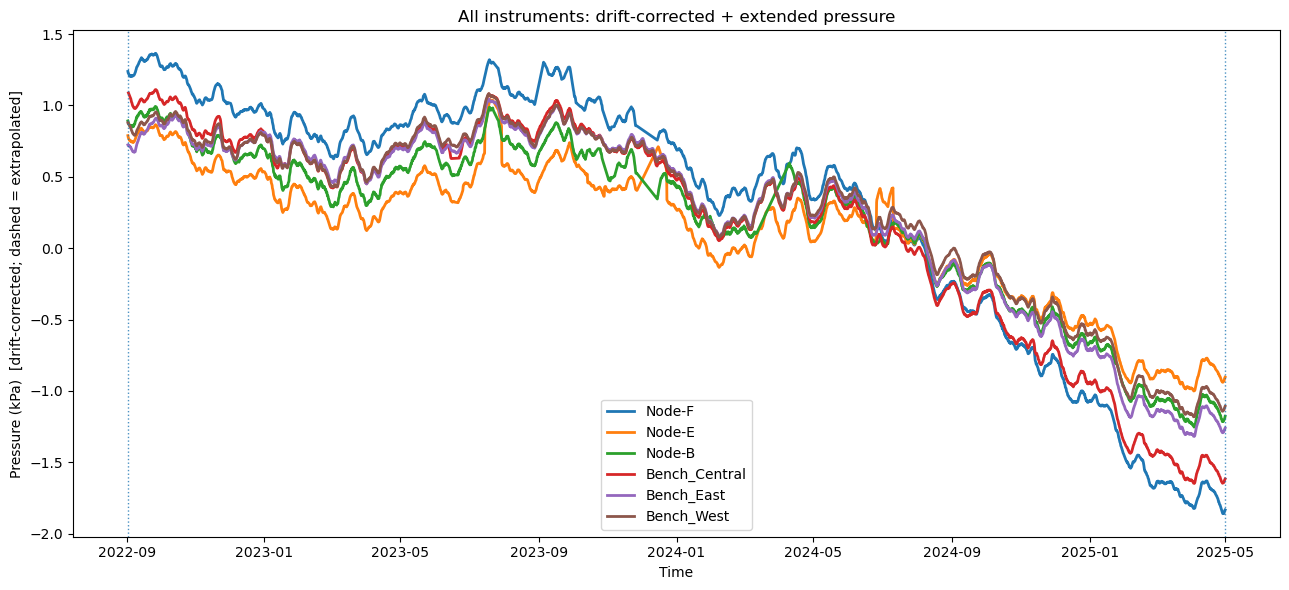

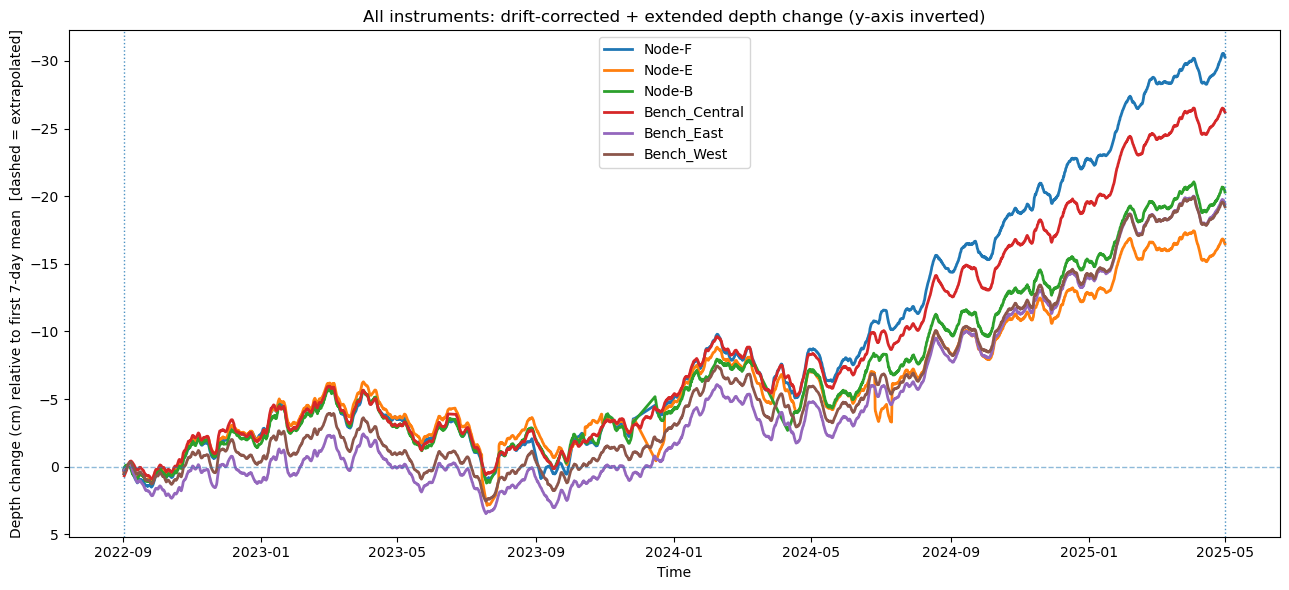

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PLOT_FREQ = "6H"      # change to "1D" if you want fewer points
BASELINE_DAYS = 7
SAMPLE_FREQ = "1H"    # for baseline mean

grid = pd.date_range(depth_start, depth_end, freq=PLOT_FREQ)

def window_mean_from_function(eval_func, t_start, t_end, freq="1H"):
    ts = pd.date_range(pd.Timestamp(t_start), pd.Timestamp(t_end), freq=freq, inclusive="left")
    vals = pd.Series(eval_func(ts), index=ts).dropna()
    return float(vals.mean()) if len(vals) else np.nan

def eval_on_grid(eval_func, grid):
    y = eval_func(grid)
    return pd.Series(y, index=grid, dtype=float)

# =========================
# 1) ALL PRESSURE (kPa)
# =========================
plt.figure(figsize=(13,6))

for name, eval_func in evaluators.items():
    sP = eval_on_grid(eval_func, grid).dropna()

    last_obs = meta.get(name, {}).get("last_obs", None)
    used_ex  = bool(meta.get(name, {}).get("used_extrapolation", False))

    if (last_obs is not None) and used_ex:
        last_obs = pd.Timestamp(last_obs)
        obs = sP.loc[sP.index <= last_obs]
        ext = sP.loc[sP.index >  last_obs]

        plt.plot(obs.index, obs.values, lw=2, label=name)
        if len(ext):
            plt.plot(ext.index, ext.values, lw=2, ls="--")  # extrapolated tail
    else:
        plt.plot(sP.index, sP.values, lw=2, label=name)

plt.axvline(pd.Timestamp(depth_start), lw=1, ls=":", alpha=0.8)
plt.axvline(pd.Timestamp(depth_end),   lw=1, ls=":", alpha=0.8)
plt.xlabel("Time")
plt.ylabel("Pressure (kPa)  [drift-corrected; dashed = extrapolated]")
plt.title("All instruments: drift-corrected + extended pressure")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 2) ALL DEPTH CHANGE (cm) + invert y-axis
# depth_change_cm(t) = (P(t) - mean(P over first 7 days)) * CM_PER_KPA
# =========================
plt.figure(figsize=(13,6))

for name, eval_func in evaluators.items():
    # baseline mean from first 7 days
    p0 = window_mean_from_function(
        eval_func,
        depth_start,
        depth_start + pd.Timedelta(days=BASELINE_DAYS),
        freq=SAMPLE_FREQ
    )
    if not np.isfinite(p0):
        continue

    sP = eval_on_grid(eval_func, grid).dropna()
    sDepth_cm = (sP - p0) * CM_PER_KPA

    last_obs = meta.get(name, {}).get("last_obs", None)
    used_ex  = bool(meta.get(name, {}).get("used_extrapolation", False))

    if (last_obs is not None) and used_ex:
        last_obs = pd.Timestamp(last_obs)
        obs = sDepth_cm.loc[sDepth_cm.index <= last_obs]
        ext = sDepth_cm.loc[sDepth_cm.index >  last_obs]

        plt.plot(obs.index, obs.values, lw=2, label=name)
        if len(ext):
            plt.plot(ext.index, ext.values, lw=2, ls="--")  # extrapolated tail
    else:
        plt.plot(sDepth_cm.index, sDepth_cm.values, lw=2, label=name)

plt.axhline(0, lw=1, ls="--", alpha=0.5)
plt.axvline(pd.Timestamp(depth_start), lw=1, ls=":", alpha=0.8)
plt.axvline(pd.Timestamp(depth_end),   lw=1, ls=":", alpha=0.8)
plt.xlabel("Time")
plt.ylabel("Depth change (cm) relative to first 7-day mean  [dashed = extrapolated]")
plt.title("All instruments: drift-corrected + extended depth change (y-axis inverted)")

# Invert y-axis as requested (so decreasing depth plots the way you want)
plt.gca().invert_yaxis()

plt.legend()
plt.tight_layout()
plt.show()
